# Create an elastic network for 7tx0 (mac1, p43 space group) and find its band structure

Goal: create a real enm and construct its Hessian & band structure

Code mostly lifted from proto-hessian.ipynb and 7tx0-enm.ipynb

Steps:

1. Use Mac1 P43 + ADPr [7TX0](https://www.rcsb.org/structure/7TX0), with two copies in the ASU. Group atoms by chain ID.
2. Pack the unit cell
3. Construct the contact list for the ASU. Keep only contacts between groups (or with other ASUs). Label springs by symmetry class indexed by w.
4. Expand to fill unit cell and add node positions
5. Delete duplicate springs due to double-counted inter-unit cell springs.
6. Create function which builds K taking diag({kLw,kTw}) as inputs. Somehow FFT to find K(q) and D(q).
7. Plot band structure along special directions. Following the TET path in [Setyawan and Curtarolo](https://arxiv.org/pdf/1004.2974), plot Γ-X-M-Γ-Z-R-A-Z|X-R|M-A.
8. Plot DOS from band structure.

In [1]:
#I will use gemmi to parse the PDB file 7tx0.cif.
#I then want to go towards constructing a Hessian for the rigid body ENM with springs organized nicely in a dataframe.
from goodvibes import enm
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import gemmi
import random
from scipy import sparse
from collections import defaultdict

# 1. Assign rigid groups

In [2]:
#A lot of these lines will be borrowed from sandbox/steve/proto-hessian.ipynb

# !cd test_data && curl -O https://files.rcsb.org/download/7TX0.cif

coordinate_file = 'test_data/7TX0.cif'

st = gemmi.read_structure(coordinate_file)
st.setup_entities()  # supposed to be good practice

print('Unit Cell:',st.cell.parameters)
print('Space Group:',st.spacegroup_hm)

groups = [
    gemmi.Selection('//A;polymer'),
    gemmi.Selection('//B;polymer'),
]

tls_groups = []

# calculate the group center of mass, store as TLS group origin
for group_id, selection in enumerate(groups):
    model = selection.copy_model_selection(st[0])
    com = model.calculate_center_of_mass()
    g = gemmi.TlsGroup()
    g.id = f"TLS{group_id}"  # why is this a string? why can't I access num_id property?
    g.origin = com
    tls_groups.append(g)

st.meta.refinement[0].tls_groups = tls_groups

for group_id, selection in enumerate(groups):
    for model in selection.models(st):
        for chain in selection.chains(model):
            for residue in selection.residues(chain):
                for atom in selection.atoms(residue):
                    atom.tls_group_id = group_id

Unit Cell: (88.451, 88.451, 39.823, 90.0, 90.0, 90.0)
Space Group: P 43


# 2. and 3. Pack unit cell and construct contact list. Label symmetry classes.

In [3]:
enm._pack_unit_cell(st, inplace=True)

df = enm._find_contacts(
   st,
   distance_cutoff=4.0,
   include_h=False,
)

def address_from_cra_string(cra):
    chain, residue, atom = cra.split('/')
    resname, seqid = residue.split()
    if '.' in atom:
        atom, altloc = atom.split('.')
    else:
        altloc = '\x00'
    addr =  gemmi.AtomAddress(chain, gemmi.SeqId(seqid), resname, atom, altloc)
    return addr

df['group_id1'] = -1
df['group_id2'] = -1

# add group ID columns to dataframe
for row in df.itertuples():
    cra1 = st[0].find_cra(address_from_cra_string(row.cra1))
    cra2 = st[0].find_cra(address_from_cra_string(row.cra2))
    df.at[row.Index, 'group_id1'] = cra1.atom.tls_group_id
    df.at[row.Index, 'group_id2'] = cra2.atom.tls_group_id

df['external'] = False

# add a column that indicates whether the contact is external (between different groups)
for row in df.itertuples():
    if row.group_id1 == -1 or row.group_id2 == -1:
        df.at[row.Index, 'external'] = False
    elif (row.sym_idx1 == row.sym_idx2) and (row.pbc_shift1 == row.pbc_shift2):
        # same ASU, check if the two residues have the same flag (i.e. belong to the same rigid group)
        df.at[row.Index, 'external'] = (row.group_id1 != row.group_id2)
    else:
        # different ASU, any group flag (not null)
        df.at[row.Index, 'external'] = True

# create a new dataframe that contains only the external contacts, dropping the 'external' column, reset index.
external_df = df[df['external']].drop(columns=['external']).reset_index(drop=True)
external_df

,cra1,cra2,sym_idx1,sym_idx2,pbc_shift1,pbc_shift2,group_id1,group_id2
0,A/GLY 8/C,A/PHE 156/CZ,0,3,"(0, 0, 0)","(0, 0, 0)",0,0
1,A/GLY 8/O,A/PHE 156/CE2,0,3,"(0, 0, 0)","(0, 0, 0)",0,0
2,A/GLY 8/O,A/PHE 156/CZ,0,3,"(0, 0, 0)","(0, 0, 0)",0,0
3,A/TYR 9/C,A/PHE 156/CZ,0,3,"(0, 0, 0)","(0, 0, 0)",0,0
4,A/TYR 9/O,A/PHE 156/CE2,0,3,"(0, 0, 0)","(0, 0, 0)",0,0
...,...,...,...,...,...,...,...,...
612,B/LEU 169/CD1,B/ASP 22/OD1,0,1,"(0, 0, 0)","(-1, 0, -1)",1,1
613,B/LEU 169/CD1,B/ASP 22/OD2,0,1,"(0, 0, 0)","(-1, 0, -1)",1,1
614,B/LEU 169/CD2,B/ILE 23/CG2,0,1,"(0, 0, 0)","(-1, 0, -1)",1,1
615,B/LEU 169/CD2,B/ALA 52/CB,0,1,"(0, 0, 0)","(-1, 0, -1)",1,1


# 4. Expand to fill unit cell and add node positions

In [4]:
external_df_expanded = enm._symmetry_expand(external_df, st.cell.images)

def transform_position(st, sym_idx, pbc_shift, pos):
    if sym_idx == 0:
        image_transform = gemmi.Transform()
    else:
        image_transform = st.cell.images[sym_idx - 1]
    pbc_transform = gemmi.Transform(gemmi.Mat33(), gemmi.Vec3(*pbc_shift))
    t = pbc_transform @ image_transform
    return st.cell.orthogonalize(gemmi.Fractional(t.apply(st.cell.fractionalize(pos))))

external_df_expanded['r1'] = pd.Series([None] * len(external_df_expanded), dtype=object)
external_df_expanded['r2'] = pd.Series([None] * len(external_df_expanded), dtype=object)

for row in external_df_expanded.itertuples():
    cra1 = st[0].find_cra(address_from_cra_string(row.cra1))
    cra2 = st[0].find_cra(address_from_cra_string(row.cra2))
    pos1 = transform_position(st, row.sym_idx1, row.pbc_shift1, cra1.atom.pos)
    pos2 = transform_position(st, row.sym_idx2, row.pbc_shift2, cra2.atom.pos)
    external_df_expanded.at[row.Index, 'r1'] = (pos1.x, pos1.y, pos1.z)
    external_df_expanded.at[row.Index, 'r2'] = (pos2.x, pos2.y, pos2.z)

external_df_expanded

,index,cra1,cra2,sym_idx1,sym_idx2,pbc_shift1,pbc_shift2,group_id1,group_id2,r1,r2
0,0,A/GLY 8/C,A/PHE 156/CZ,0,3,"(0, 0, 0)","(0, 0, 0)",0,0,"(36.19777, 35.47873, 15.606150000000001)","(33.5479, 38.297419999999995, 15.76611)"
1,1,A/GLY 8/O,A/PHE 156/CE2,0,3,"(0, 0, 0)","(0, 0, 0)",0,0,"(36.59681, 36.19113, 14.68052)","(34.09091, 38.94922, 14.69258)"
2,2,A/GLY 8/O,A/PHE 156/CZ,0,3,"(0, 0, 0)","(0, 0, 0)",0,0,"(36.59681, 36.19113, 14.68052)","(33.5479, 38.297419999999995, 15.76611)"
3,3,A/TYR 9/C,A/PHE 156/CZ,0,3,"(0, 0, 0)","(0, 0, 0)",0,0,"(33.53765, 35.06444, 13.83823)","(33.5479, 38.297419999999995, 15.76611)"
4,4,A/TYR 9/O,A/PHE 156/CE2,0,3,"(0, 0, 0)","(0, 0, 0)",0,0,"(32.68961, 35.29065, 14.70957)","(34.09091, 38.94922, 14.69258)"
...,...,...,...,...,...,...,...,...,...,...,...
2208,612,B/LEU 169/CD1,B/ASP 22/OD1,3,0,"(0, 0, 0)","(0, 1, 0)",1,1,"(15.612220000000002, 79.41917, -4.556659999999...","(17.4578, 79.14677999999999, -7.70419)"
2209,613,B/LEU 169/CD1,B/ASP 22/OD2,3,0,"(0, 0, 0)","(0, 1, 0)",1,1,"(15.612220000000002, 79.41917, -4.556659999999...","(15.84539, 77.71637999999999, -7.72701)"
2210,614,B/LEU 169/CD2,B/ILE 23/CG2,3,0,"(0, 0, 0)","(0, 1, 0)",1,1,"(17.03124, 81.20943, -3.626659999999998)","(19.34131, 83.05068999999999, -5.65706)"
2211,615,B/LEU 169/CD2,B/ALA 52/CB,3,0,"(0, 0, 0)","(0, 1, 0)",1,1,"(17.03124, 81.20943, -3.626659999999998)","(18.87069, 78.58950999999999, -1.90476)"


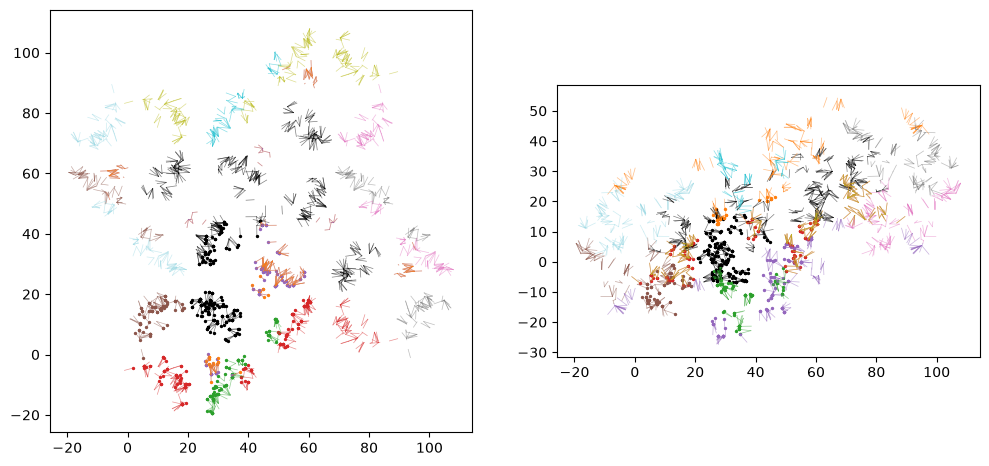

In [5]:
# plot the external contacts as lines in 2d projections.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# assign unique values of pbc_shift2 to colors
unique_pbc_shifts = external_df_expanded['pbc_shift2'].unique()
colors = plt.colormaps['tab20'].resampled(len(unique_pbc_shifts))

for row in external_df_expanded.itertuples():
    # if row.sym_idx1 != 0:
    #     continue  # only plot contacts from the reference ASU
    x1, y1, z1 = row.r1
    x2, y2, z2 = row.r2
    # color by pbc_shift1 and pbc_shift2 not 0,0,0
    color = colors(list(unique_pbc_shifts).index(row.pbc_shift2)) if row.pbc_shift2 != (0, 0, 0) else 'k'

    ax1.plot([x1, x2], [y1, y2], color=color, alpha=0.5, linewidth=.5)
    ax2.plot([x1, x2], [z1, z2], color=color, alpha=0.5, linewidth=.5)
    if row.sym_idx1 == 0:
        ax1.scatter(x1, y1, color=color, s=2)
        ax2.scatter(x1, z1, color=color, s=2)
    if (row.pbc_shift2 == (0, 0, 0)) and (row.sym_idx2 == 0):
        ax1.scatter(x2, y2, color=color, s=2)
        ax2.scatter(x2, z2, color=color, s=2)
# equal aspect
ax1.set_aspect('equal', 'box')
ax2.set_aspect('equal', 'box')

# 5. Delete duplicate springs due to PBC

In [6]:
# How to handle PBC? I think with current expanded model, the springs between unit cells will be double-counted.
# Can detect this, I think, by dropping the pbc_shift columns and finding unique edges.

external_df_expanded_pbc = external_df_expanded.copy()

#Sort based on cra and sym_idx
for row in external_df_expanded.itertuples():
    if (row.cra1, row.sym_idx1) > (row.cra2, row.sym_idx2):
        external_df_expanded_pbc.at[row.Index, 'cra1'] = row.cra2
        external_df_expanded_pbc.at[row.Index, 'sym_idx1'] = row.sym_idx2
        external_df_expanded_pbc.at[row.Index, 'pbc_shift1'] = row.pbc_shift2
        external_df_expanded_pbc.at[row.Index, 'group_id1'] = row.group_id2
        external_df_expanded_pbc.at[row.Index, 'r1'] = row.r2
        external_df_expanded_pbc.at[row.Index, 'cra2'] = row.cra1
        external_df_expanded_pbc.at[row.Index, 'sym_idx2'] = row.sym_idx1
        external_df_expanded_pbc.at[row.Index, 'pbc_shift2'] = row.pbc_shift1
        external_df_expanded_pbc.at[row.Index, 'group_id2'] = row.group_id1
        external_df_expanded_pbc.at[row.Index, 'r2'] = row.r1

external_df_expanded_pbc.drop_duplicates(subset=['cra1','cra2','sym_idx1','sym_idx2'],inplace=True)
external_df_expanded_pbc.reset_index(drop=True,inplace=True)

#swap sites 1 and 2 again so that cra1 is back inside the unit cell.
for row in external_df_expanded_pbc.itertuples():
    if row.pbc_shift1!=(0,0,0):
        external_df_expanded_pbc.at[row.Index, 'cra1'] = row.cra2
        external_df_expanded_pbc.at[row.Index, 'sym_idx1'] = row.sym_idx2
        external_df_expanded_pbc.at[row.Index, 'pbc_shift1'] = row.pbc_shift2
        external_df_expanded_pbc.at[row.Index, 'group_id1'] = row.group_id2
        external_df_expanded_pbc.at[row.Index, 'r1'] = row.r2
        external_df_expanded_pbc.at[row.Index, 'cra2'] = row.cra1
        external_df_expanded_pbc.at[row.Index, 'sym_idx2'] = row.sym_idx1
        external_df_expanded_pbc.at[row.Index, 'pbc_shift2'] = row.pbc_shift1
        external_df_expanded_pbc.at[row.Index, 'group_id2'] = row.group_id1
        external_df_expanded_pbc.at[row.Index, 'r2'] = row.r1
external_df_expanded_pbc

,index,cra1,cra2,sym_idx1,sym_idx2,pbc_shift1,pbc_shift2,group_id1,group_id2,r1,r2
0,0,A/GLY 8/C,A/PHE 156/CZ,0,3,"(0, 0, 0)","(0, 0, 0)",0,0,"(36.19777, 35.47873, 15.606150000000001)","(33.5479, 38.297419999999995, 15.76611)"
1,1,A/GLY 8/O,A/PHE 156/CE2,0,3,"(0, 0, 0)","(0, 0, 0)",0,0,"(36.59681, 36.19113, 14.68052)","(34.09091, 38.94922, 14.69258)"
2,2,A/GLY 8/O,A/PHE 156/CZ,0,3,"(0, 0, 0)","(0, 0, 0)",0,0,"(36.59681, 36.19113, 14.68052)","(33.5479, 38.297419999999995, 15.76611)"
3,3,A/PHE 156/CZ,A/TYR 9/C,3,0,"(0, 0, 0)","(0, 0, 0)",0,0,"(33.5479, 38.297419999999995, 15.76611)","(33.53765, 35.06444, 13.83823)"
4,4,A/PHE 156/CE2,A/TYR 9/O,3,0,"(0, 0, 0)","(0, 0, 0)",0,0,"(34.09091, 38.94922, 14.69258)","(32.68961, 35.29065, 14.70957)"
...,...,...,...,...,...,...,...,...,...,...,...
1395,382,B/ASN 4/O,B/TYR 42/OH.B,3,3,"(0, 0, 0)","(0, 0, -1)",1,1,"(0.10113000000000001, 61.87219999999999, -8.78...","(-0.9083000000000001, 61.58114, -12.4373400000..."
1396,383,B/SER 5/CA.B,B/TYR 42/OH.B,3,3,"(0, 0, 0)","(0, 0, -1)",1,1,"(-2.25059, 62.814809999999994, -9.76083)","(-0.9083000000000001, 61.58114, -12.4373400000..."
1397,384,B/SER 5/CB.B,B/TYR 42/CE2.B,3,3,"(0, 0, 0)","(0, 0, -1)",1,1,"(-3.511, 62.45516, -10.531149999999998)","(-2.07505, 62.62223, -14.22047)"
1398,385,B/SER 5/CB.B,B/TYR 42/CZ.B,3,3,"(0, 0, 0)","(0, 0, -1)",1,1,"(-3.511, 62.45516, -10.531149999999998)","(-1.64307, 61.47500999999999, -13.60131)"


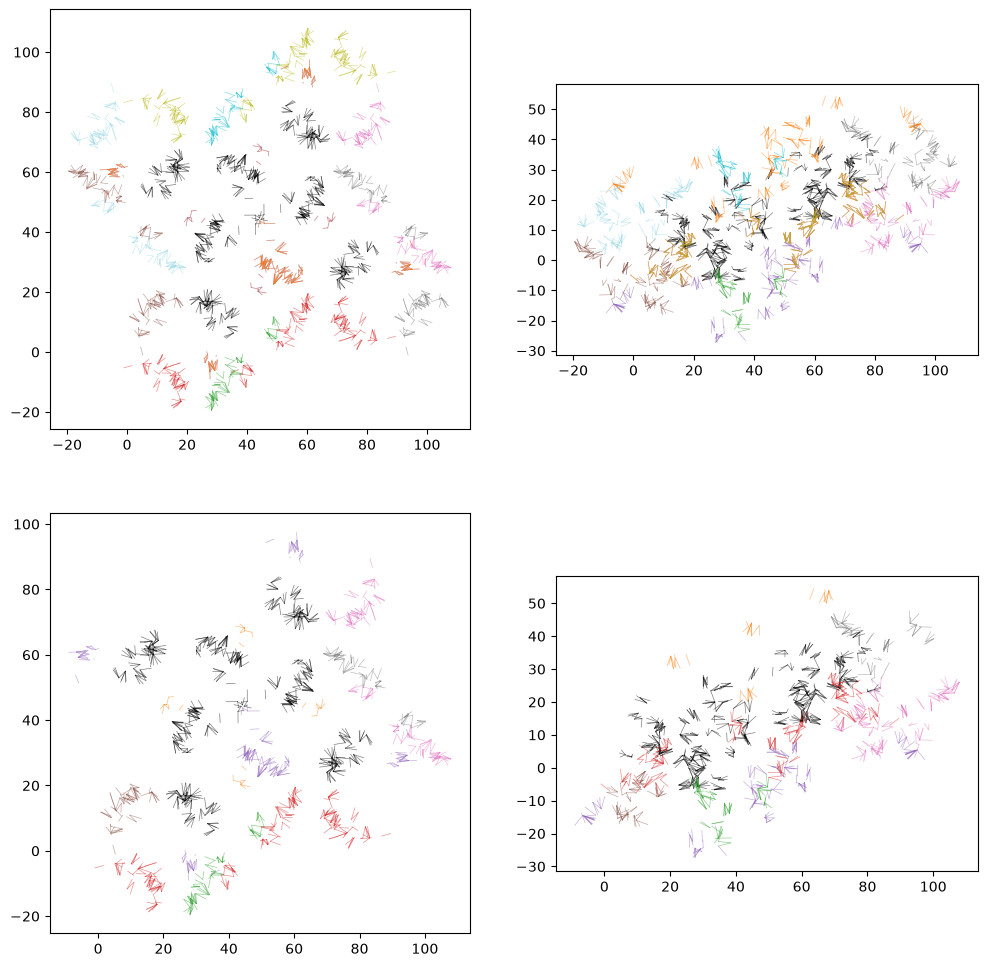

In [7]:
# plot the external contacts as lines in 2d projections.
fig, (ax1, ax2) = plt.subplots(2, 2, figsize=(12, 12))

# assign unique values of pbc_shift2 to colors
unique_pbc_shifts = external_df_expanded['pbc_shift2'].unique()
colors = plt.colormaps['tab20'].resampled(len(unique_pbc_shifts))

for row in external_df_expanded.itertuples():
    # if row.sym_idx1 != 0:
    #     continue  # only plot contacts from the reference ASU
    x1, y1, z1 = row.r1
    x2, y2, z2 = row.r2
    # color by pbc_shift1 and pbc_shift2 not 0,0,0
    color = colors(list(unique_pbc_shifts).index(row.pbc_shift2)) if row.pbc_shift2 != (0, 0, 0) else 'k'

    ax1[0].plot([x1, x2], [y1, y2], color=color, alpha=0.5, linewidth=.5)
    ax1[1].plot([x1, x2], [z1, z2], color=color, alpha=0.5, linewidth=.5)

for row in external_df_expanded_pbc.itertuples():
    # if row.sym_idx1 != 0:
    #     continue  # only plot contacts from the reference ASU
    x1, y1, z1 = row.r1
    x2, y2, z2 = row.r2
    # color by pbc_shift1 and pbc_shift2 not 0,0,0
    color = colors(list(unique_pbc_shifts).index(row.pbc_shift2)) if row.pbc_shift2 != (0, 0, 0) else 'k'

    ax2[0].plot([x1, x2], [y1, y2], color=color, alpha=0.5, linewidth=.5)
    ax2[1].plot([x1, x2], [z1, z2], color=color, alpha=0.5, linewidth=.5)
# equal aspect
ax1[0].set_aspect('equal', 'box')
ax1[1].set_aspect('equal', 'box')
ax2[0].set_aspect('equal', 'box')
ax2[1].set_aspect('equal', 'box')

In [8]:
#sanity check on number of bonds:
#for unit cell with double counting, N1 = N_intra + 2*N_inter.
#for unit cell without double counting, N2 = N_intra + N_inter.
N_intra1 = len(external_df_expanded.loc[external_df_expanded['pbc_shift2']==(0,0,0)])
N_intra2 = len(external_df_expanded_pbc.loc[external_df_expanded_pbc['pbc_shift2']==(0,0,0)])
#make sure we have the same number of intra-springs.
print(N_intra1==N_intra2)
#make sure we have half the original number of inter-springs.
N_inter1 = len(external_df_expanded)-N_intra1
N_inter2 = len(external_df_expanded_pbc)-N_intra2
print(N_inter1==2*N_inter2)

True
True


In [9]:
#symmetry groups w can be found just by checking which atoms are connected. Group by cra1 and cra2. Springs that are symmetry-related connect the same cra1 and cra2.
df_symmetry = external_df_expanded_pbc.copy()
#delete columns: cra1 is always in unit cell, n1, n2 extraneous for now.
df_symmetry = df_symmetry.drop(columns = ['pbc_shift1'])
#rename column: pbc_shift is the vector pointing from the unit cell of cra1 to the unit cell of cra2.
df_symmetry = df_symmetry.rename(columns={'pbc_shift2':'pbc_shift'})
df_symmetry

,index,cra1,cra2,sym_idx1,sym_idx2,pbc_shift,group_id1,group_id2,r1,r2
0,0,A/GLY 8/C,A/PHE 156/CZ,0,3,"(0, 0, 0)",0,0,"(36.19777, 35.47873, 15.606150000000001)","(33.5479, 38.297419999999995, 15.76611)"
1,1,A/GLY 8/O,A/PHE 156/CE2,0,3,"(0, 0, 0)",0,0,"(36.59681, 36.19113, 14.68052)","(34.09091, 38.94922, 14.69258)"
2,2,A/GLY 8/O,A/PHE 156/CZ,0,3,"(0, 0, 0)",0,0,"(36.59681, 36.19113, 14.68052)","(33.5479, 38.297419999999995, 15.76611)"
3,3,A/PHE 156/CZ,A/TYR 9/C,3,0,"(0, 0, 0)",0,0,"(33.5479, 38.297419999999995, 15.76611)","(33.53765, 35.06444, 13.83823)"
4,4,A/PHE 156/CE2,A/TYR 9/O,3,0,"(0, 0, 0)",0,0,"(34.09091, 38.94922, 14.69258)","(32.68961, 35.29065, 14.70957)"
...,...,...,...,...,...,...,...,...,...,...
1395,382,B/ASN 4/O,B/TYR 42/OH.B,3,3,"(0, 0, -1)",1,1,"(0.10113000000000001, 61.87219999999999, -8.78...","(-0.9083000000000001, 61.58114, -12.4373400000..."
1396,383,B/SER 5/CA.B,B/TYR 42/OH.B,3,3,"(0, 0, -1)",1,1,"(-2.25059, 62.814809999999994, -9.76083)","(-0.9083000000000001, 61.58114, -12.4373400000..."
1397,384,B/SER 5/CB.B,B/TYR 42/CE2.B,3,3,"(0, 0, -1)",1,1,"(-3.511, 62.45516, -10.531149999999998)","(-2.07505, 62.62223, -14.22047)"
1398,385,B/SER 5/CB.B,B/TYR 42/CZ.B,3,3,"(0, 0, -1)",1,1,"(-3.511, 62.45516, -10.531149999999998)","(-1.64307, 61.47500999999999, -13.60131)"


In [10]:
df_symmetry.sort_values(by=['index'])

,index,cra1,cra2,sym_idx1,sym_idx2,pbc_shift,group_id1,group_id2,r1,r2
0,0,A/GLY 8/C,A/PHE 156/CZ,0,3,"(0, 0, 0)",0,0,"(36.19777, 35.47873, 15.606150000000001)","(33.5479, 38.297419999999995, 15.76611)"
1,1,A/GLY 8/O,A/PHE 156/CE2,0,3,"(0, 0, 0)",0,0,"(36.59681, 36.19113, 14.68052)","(34.09091, 38.94922, 14.69258)"
2,2,A/GLY 8/O,A/PHE 156/CZ,0,3,"(0, 0, 0)",0,0,"(36.59681, 36.19113, 14.68052)","(33.5479, 38.297419999999995, 15.76611)"
3,3,A/PHE 156/CZ,A/TYR 9/C,3,0,"(0, 0, 0)",0,0,"(33.5479, 38.297419999999995, 15.76611)","(33.53765, 35.06444, 13.83823)"
4,4,A/PHE 156/CE2,A/TYR 9/O,3,0,"(0, 0, 0)",0,0,"(34.09091, 38.94922, 14.69258)","(32.68961, 35.29065, 14.70957)"
...,...,...,...,...,...,...,...,...,...,...
1285,615,B/LEU 169/CD2,B/ALA 52/CB,2,3,"(1, 0, 0)",1,1,"(81.20943, 71.41976, 6.329090000000002)","(78.58950999999999, 69.58031, 8.05099)"
1017,615,B/LEU 169/CD2,B/ALA 52/CB,1,2,"(0, -1, 0)",1,1,"(71.41976, 7.24157, 16.284840000000003)","(69.58031, 9.86149, 18.00674)"
586,616,B/LEU 169/OXT,B/PHE 156/CB,0,1,"(-1, 0, -1)",1,1,"(3.92057, 13.5496, -12.55955)","(5.5451, 12.20417, -15.91071)"
1286,616,B/LEU 169/OXT,B/PHE 156/CB,2,3,"(1, 0, 0)",1,1,"(84.53043, 74.9014, 7.35195)","(82.9059, 76.24683, 4.00079)"


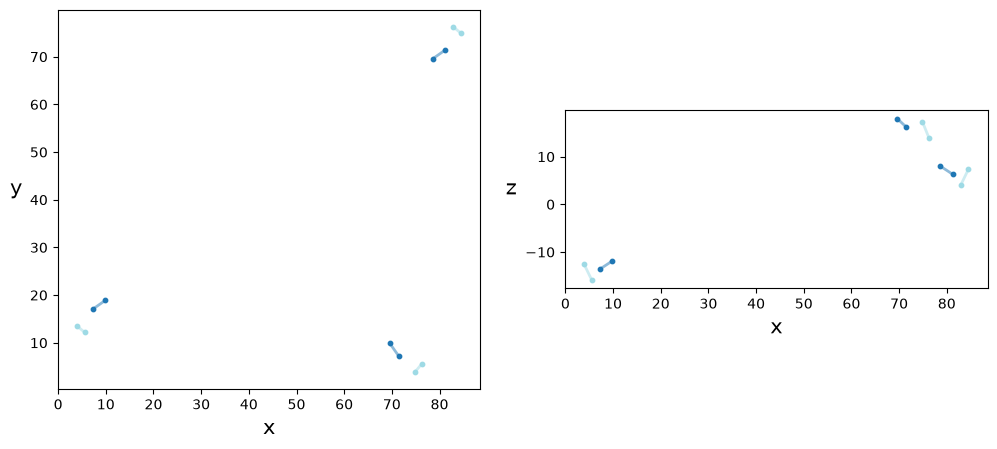

In [11]:
#sanity check - plot the bonds in the first symmetry class
# plot the external contacts as lines in 2d projections.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

ws = [615,616]
colors = plt.colormaps['tab20'].resampled(len(ws))

for row in df_symmetry.itertuples():
    if row.index not in ws:
         continue  # only plot contacts from certain symmetry classes
    x1, y1, z1 = row.r1
    x2, y2, z2 = row.r2
    color = colors(list(ws).index(row.index))
    ax1.plot([x1, x2], [y1, y2], alpha=0.5, linewidth=2, color=color)
    ax2.plot([x1, x2], [z1, z2], alpha=0.5, linewidth=2, color=color)
    ax1.scatter(x1, y1, color=color, s=10)
    ax1.scatter(x2, y2, color=color, s=10)
    ax2.scatter(x1, z1, color=color, s=10)
    ax2.scatter(x2, z2, color=color, s=10)
# labels
ax1.set_xlabel('x',fontsize=15)
ax1.set_ylabel('y',rotation=0,fontsize=15,labelpad=10)
ax2.set_xlabel('x',fontsize=15)
ax2.set_ylabel('z',rotation=0,fontsize=15,labelpad=10)
# equal aspect
ax1.set_aspect('equal', 'box')
ax2.set_aspect('equal', 'box')

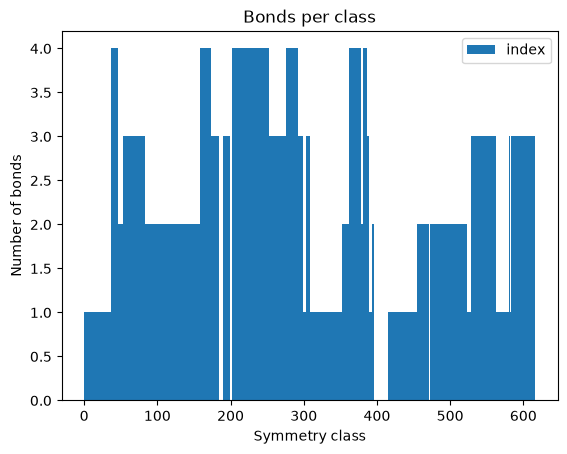

In [12]:
# Select row by its index label and plot its value distribution
df_symmetry.plot.hist(column=['index'],bins=617)

plt.title("Bonds per class")
plt.xlabel("Symmetry class")
plt.ylabel("Number of bonds")
plt.show()

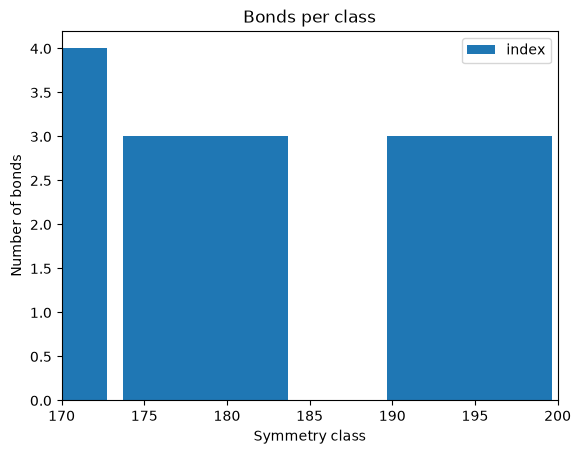

In [13]:
# Select row by its index label and plot its value distribution
df_symmetry.plot.hist(column=['index'],bins=617)

plt.title("Bonds per class")
plt.xlabel("Symmetry class")
plt.ylabel("Number of bonds")
plt.xlim((170,200))
plt.show()

In [14]:
external_df.iloc[[185]]

,cra1,cra2,sym_idx1,sym_idx2,pbc_shift1,pbc_shift2,group_id1,group_id2
185,A/LYS 102/O,A/LYS 31/CD.A,0,0,"(0, 0, 0)","(0, 0, -1)",0,0


In [15]:
external_df.iloc[[44]]

,cra1,cra2,sym_idx1,sym_idx2,pbc_shift1,pbc_shift2,group_id1,group_id2
44,A/LYS 31/CD.A,A/LYS 102/O,0,0,"(0, 0, 0)","(0, 0, 1)",0,0


In [16]:
external_df_expanded.iloc[[185]]

,index,cra1,cra2,sym_idx1,sym_idx2,pbc_shift1,pbc_shift2,group_id1,group_id2,r1,r2
185,185,A/LYS 102/O,A/LYS 31/CD.A,0,0,"(0, 0, 0)","(0, 0, -1)",0,0,"(43.69851, 20.18, -15.85842)","(45.04918000000001, 19.06019, -18.68401)"


In [17]:
external_df_expanded.iloc[[44]]

,index,cra1,cra2,sym_idx1,sym_idx2,pbc_shift1,pbc_shift2,group_id1,group_id2,r1,r2
44,44,A/LYS 31/CD.A,A/LYS 102/O,0,0,"(0, 0, 0)","(0, 0, 1)",0,0,"(45.04918000000001, 19.06019, 21.13899)","(43.69851, 20.18, 23.96458)"


In [18]:
mapping = {x: i for i, x in enumerate(sorted(df_symmetry["index"].unique()))}
df_symmetry["index"] = df_symmetry["index"].map(mapping)

In [19]:
df_symmetry.sort_values(by=['index'])

,index,cra1,cra2,sym_idx1,sym_idx2,pbc_shift,group_id1,group_id2,r1,r2
0,0,A/GLY 8/C,A/PHE 156/CZ,0,3,"(0, 0, 0)",0,0,"(36.19777, 35.47873, 15.606150000000001)","(33.5479, 38.297419999999995, 15.76611)"
1,1,A/GLY 8/O,A/PHE 156/CE2,0,3,"(0, 0, 0)",0,0,"(36.59681, 36.19113, 14.68052)","(34.09091, 38.94922, 14.69258)"
2,2,A/GLY 8/O,A/PHE 156/CZ,0,3,"(0, 0, 0)",0,0,"(36.59681, 36.19113, 14.68052)","(33.5479, 38.297419999999995, 15.76611)"
3,3,A/PHE 156/CZ,A/TYR 9/C,3,0,"(0, 0, 0)",0,0,"(33.5479, 38.297419999999995, 15.76611)","(33.53765, 35.06444, 13.83823)"
4,4,A/PHE 156/CE2,A/TYR 9/O,3,0,"(0, 0, 0)",0,0,"(34.09091, 38.94922, 14.69258)","(32.68961, 35.29065, 14.70957)"
...,...,...,...,...,...,...,...,...,...,...
1285,585,B/LEU 169/CD2,B/ALA 52/CB,2,3,"(1, 0, 0)",1,1,"(81.20943, 71.41976, 6.329090000000002)","(78.58950999999999, 69.58031, 8.05099)"
1017,585,B/LEU 169/CD2,B/ALA 52/CB,1,2,"(0, -1, 0)",1,1,"(71.41976, 7.24157, 16.284840000000003)","(69.58031, 9.86149, 18.00674)"
586,586,B/LEU 169/OXT,B/PHE 156/CB,0,1,"(-1, 0, -1)",1,1,"(3.92057, 13.5496, -12.55955)","(5.5451, 12.20417, -15.91071)"
1286,586,B/LEU 169/OXT,B/PHE 156/CB,2,3,"(1, 0, 0)",1,1,"(84.53043, 74.9014, 7.35195)","(82.9059, 76.24683, 4.00079)"


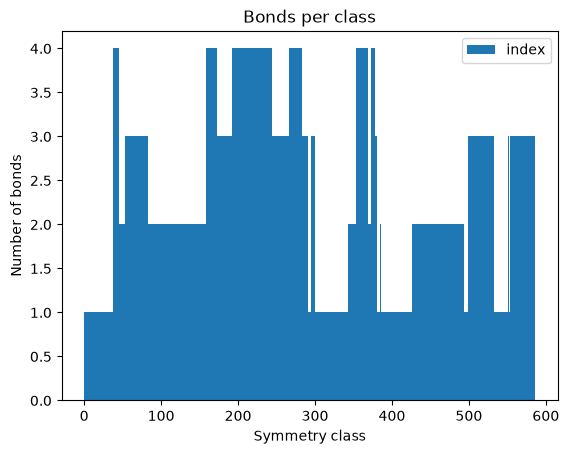

In [20]:
# Select row by its index label and plot its value distribution
df_symmetry.plot.hist(column=['index'],bins=587)

plt.title("Bonds per class")
plt.xlabel("Symmetry class")
plt.ylabel("Number of bonds")
plt.show()

In [21]:
symm_classes = df_symmetry.sort_values(by=['index']).iloc[[-1]]['index'].tolist()[0]+1

In [22]:
symm_classes

587

In [23]:
df_symmetry

,index,cra1,cra2,sym_idx1,sym_idx2,pbc_shift,group_id1,group_id2,r1,r2
0,0,A/GLY 8/C,A/PHE 156/CZ,0,3,"(0, 0, 0)",0,0,"(36.19777, 35.47873, 15.606150000000001)","(33.5479, 38.297419999999995, 15.76611)"
1,1,A/GLY 8/O,A/PHE 156/CE2,0,3,"(0, 0, 0)",0,0,"(36.59681, 36.19113, 14.68052)","(34.09091, 38.94922, 14.69258)"
2,2,A/GLY 8/O,A/PHE 156/CZ,0,3,"(0, 0, 0)",0,0,"(36.59681, 36.19113, 14.68052)","(33.5479, 38.297419999999995, 15.76611)"
3,3,A/PHE 156/CZ,A/TYR 9/C,3,0,"(0, 0, 0)",0,0,"(33.5479, 38.297419999999995, 15.76611)","(33.53765, 35.06444, 13.83823)"
4,4,A/PHE 156/CE2,A/TYR 9/O,3,0,"(0, 0, 0)",0,0,"(34.09091, 38.94922, 14.69258)","(32.68961, 35.29065, 14.70957)"
...,...,...,...,...,...,...,...,...,...,...
1395,373,B/ASN 4/O,B/TYR 42/OH.B,3,3,"(0, 0, -1)",1,1,"(0.10113000000000001, 61.87219999999999, -8.78...","(-0.9083000000000001, 61.58114, -12.4373400000..."
1396,374,B/SER 5/CA.B,B/TYR 42/OH.B,3,3,"(0, 0, -1)",1,1,"(-2.25059, 62.814809999999994, -9.76083)","(-0.9083000000000001, 61.58114, -12.4373400000..."
1397,375,B/SER 5/CB.B,B/TYR 42/CE2.B,3,3,"(0, 0, -1)",1,1,"(-3.511, 62.45516, -10.531149999999998)","(-2.07505, 62.62223, -14.22047)"
1398,376,B/SER 5/CB.B,B/TYR 42/CZ.B,3,3,"(0, 0, -1)",1,1,"(-3.511, 62.45516, -10.531149999999998)","(-1.64307, 61.47500999999999, -13.60131)"


In [24]:
"""
Fast construction of the rigid-body dynamical matrix D(q) on a commensurate
q-grid, via real-space accumulation of 6x6 blocks followed by an FFT.

ASSUMED INPUTS
--------------
df_symmetry : one row per *unique* spring (no inter-cell double-counting),
    with columns:
        index        - int, symmetry-equivalence class w
        cra1, cra2   - atom identifiers (unused directly here, kept for bookkeeping)
        sym_idx1, sym_idx2 - which symmetry op generates each atom's rigid body
        group_id1, group_id2 - which rigid body in the asymmetric unit (0,1,...)
        pbc_shift    - length-3 int array/tuple, lattice-vector offset from
                       cra1's cell to cra2's cell
        r1, r2       - length-3 Cartesian coordinates of the two spring endpoints

df_atoms : one row per atom in the unit cell (ALL M rigid bodies), needed to
    compute each body's center of mass and generalized mass matrix. Columns:
        sym_idx, group_id, mass, x, y, z
    This is NOT contained in df_symmetry (which only carries the two bonded
    atoms per row) and must be supplied separately.

lattice : 3x3 array, rows = real-space lattice vectors a1, a2, a3 (Cartesian),
    used to convert integer pbc_shift into a Cartesian offset vector.

grid_shape : (N1, N2, N3), the Born-von Karman supercell / q-grid dimensions.
    pbc_shift components must be well within this range (spring cutoff should
    be much smaller than the supercell in every direction, or wraparound will
    alias distinct neighbor images together).

CONVENTIONS
-----------
- Phi0 = kL * n n^T + kT * (I - n n^T) is the *positive* single-spring
  stiffness matrix; L/T amplitudes are refined separately per symmetry class.
- Rigid-body DOF ordering per body: (u_x, u_y, u_z, omega_x, omega_y, omega_z).
- T_i = [I3 | -skew(dr_i)] maps body DOF to atomic displacement.
- The FFT sign convention here is the numpy default (exp(-2*pi*i*h.R/N)).
  Verify this matches how you define q from grid index h elsewhere in your
  pipeline (structure factors, etc.) -- if it's backwards, swap fftn<->ifftn
  or negate q; this is purely a labeling convention and does not affect
  physical content, but must be self-consistent.
"""
# ----------------------------------------------------------------------
# small helpers
# ----------------------------------------------------------------------

def skew(v):
    """3x3 cross-product matrix: skew(v) @ w == v x w."""
    return np.array([[0.0, -v[2], v[1]],
                      [v[2], 0.0, -v[0]],
                      [-v[1], v[0], 0.0]])


def T_matrix(dr):
    """3x6 projector: atomic displacement = T_matrix(dr) @ (u; omega)."""
    return np.hstack([np.eye(3), -skew(dr)])


# ----------------------------------------------------------------------
# Step 0: rigid-body definitions, CM, generalized mass matrix, Cholesky
# ----------------------------------------------------------------------

def build_rigid_bodies(df_atoms):
    """
    Group atoms by (sym_idx, group_id) -> one rigid body each.

    Returns
    -------
    body_index : dict (sym_idx, group_id) -> mu   (mu = 0..M-1)
    CM         : (M, 3) array, center of mass of each body (reference cell)
    L          : (M, 6, 6) array, Cholesky factors (M_gen = L @ L.T) per body
    """
    keys = sorted(set(zip(df_atoms['sym_idx'], df_atoms['group_id'])))
    body_index = {k: i for i, k in enumerate(keys)}
    M = len(keys)

    CM = np.zeros((M, 3))
    Mgen = np.zeros((M, 6, 6))

    for (sym_idx, group_id), mu in body_index.items():
        sel = (df_atoms['sym_idx'] == sym_idx) & (df_atoms['group_id'] == group_id)
        sub = df_atoms[sel]
        m = sub['mass'].to_numpy(dtype=float)
        pos = sub[['x', 'y', 'z']].to_numpy(dtype=float)

        cm = (m[:, None] * pos).sum(axis=0) / m.sum()
        CM[mu] = cm
        dr = pos - cm

        m_tot = m.sum()
        S = np.zeros((3, 3))      # sum m_i skew(dr_i); ~0 if cm is exact
        Itens = np.zeros((3, 3))  # moment-of-inertia tensor about CM
        for mi, dri in zip(m, dr):
            S += mi * skew(dri)
            Itens += mi * (dri @ dri * np.eye(3) - np.outer(dri, dri))

        Mg = np.zeros((6, 6))
        Mg[:3, :3] = m_tot * np.eye(3)
        Mg[:3, 3:] = -S
        Mg[3:, :3] = S          # S is skew-symmetric, so S.T = -S = (-S).T consistent
        Mg[3:, 3:] = Itens
        Mgen[mu] = Mg

    L = np.zeros((M, 6, 6))
    for mu in range(M):
        L[mu] = np.linalg.cholesky(Mgen[mu])

    return body_index, CM, L


# ----------------------------------------------------------------------
# Step 1: accumulate real-space 6x6 blocks per symmetry class, per (mu,nu,R)
# ----------------------------------------------------------------------

def accumulate_real_space_blocks(df_symmetry, body_index, CM, lattice, grid_shape):
    """
    Returns
    -------
    classes : sorted list of symmetry-class labels w
    real_L, real_T : dense arrays, shape (W, M, M, N1, N2, N3, 6, 6)
        Un-mass-weighted, real-valued, longitudinal/transverse geometric blocks.
    """
    M = len(body_index)
    N1, N2, N3 = grid_shape
    grid = np.array(grid_shape)

    classes = sorted(df_symmetry['index'].unique())
    widx = {w: k for k, w in enumerate(classes)}
    W = len(classes)

    raw_L = defaultdict(lambda: np.zeros((6, 6)))
    raw_T = defaultdict(lambda: np.zeros((6, 6)))

    for row in df_symmetry.itertuples(index=False):
        w = row.index
        mu = body_index[(row.sym_idx1, row.group_id1)]
        nu = body_index[(row.sym_idx2, row.group_id2)]

        Rvec = np.asarray(row.pbc_shift, dtype=int)
        Rcart = Rvec @ lattice

        r1 = np.asarray(row.r1, dtype=float)
        r2 = np.asarray(row.r2, dtype=float)

        dr1 = r1 - CM[mu]
        dr2 = (r2 - Rcart) - CM[nu]   # bring cra2 back to its reference-cell image

        d = r1 - r2
        dist = np.linalg.norm(d)
        n = d / dist
        Phi_L = np.outer(n, n)
        Phi_T = np.eye(3) - Phi_L

        T1 = T_matrix(dr1)
        T2 = T_matrix(dr2)

        blk11_L = T1.T @ Phi_L @ T1
        blk22_L = T2.T @ Phi_L @ T2
        blk12_L = -T1.T @ Phi_L @ T2
        blk21_L = blk12_L.T           # Phi_L symmetric real -> exact transpose

        blk11_T = T1.T @ Phi_T @ T1
        blk22_T = T2.T @ Phi_T @ T2
        blk12_T = -T1.T @ Phi_T @ T2
        blk21_T = blk12_T.T

        R0 = (0, 0, 0)
        Rmod = tuple(Rvec % grid)
        Rneg = tuple((-Rvec) % grid)

        raw_L[(w, mu, mu, R0)] += blk11_L
        raw_L[(w, nu, nu, R0)] += blk22_L
        raw_L[(w, mu, nu, Rmod)] += blk12_L
        raw_L[(w, nu, mu, Rneg)] += blk21_L

        raw_T[(w, mu, mu, R0)] += blk11_T
        raw_T[(w, nu, nu, R0)] += blk22_T
        raw_T[(w, mu, nu, Rmod)] += blk12_T
        raw_T[(w, nu, mu, Rneg)] += blk21_T

    real_L = np.zeros((W, M, M, N1, N2, N3, 6, 6))
    real_T = np.zeros((W, M, M, N1, N2, N3, 6, 6))
    for (w, mu, nu, R), blk in raw_L.items():
        real_L[widx[w], mu, nu, R[0], R[1], R[2]] += blk
    for (w, mu, nu, R), blk in raw_T.items():
        real_T[widx[w], mu, nu, R[0], R[1], R[2]] += blk

    return classes, real_L, real_T


# ----------------------------------------------------------------------
# Step 2: mass-weight (once, in real space) then FFT to get S_L^w(q), S_T^w(q)
# ----------------------------------------------------------------------

def mass_weight_blocks(real_blocks, L):
    """
    Apply Linv[mu] @ block @ Linv[nu].T to every (w, mu, nu, R) block.
    real_blocks: (W, M, M, N1, N2, N3, 6, 6)
    L: (M, 6, 6) Cholesky factors
    """
    M = L.shape[0]
    Linv = np.linalg.inv(L)  # (M,6,6); fine for 6x6, or use solve_triangular
    # out[w,mu,nu,R,a,d] = sum_bc Linv[mu,a,b] * blk[w,mu,nu,R,b,c] * Linv[nu,d,c]
    out = np.einsum('mab,wmnijkbc,ndc->wmnijkad', Linv, real_blocks, Linv,
                     optimize=True)
    return out


def fourier_transform_blocks(mass_weighted_blocks):
    """FFT along the three lattice-offset axes (axes 3,4,5)."""
    return np.fft.fftn(mass_weighted_blocks, axes=(3, 4, 5))


# ----------------------------------------------------------------------
# One-time setup: run once, cache S_L_fft / S_T_fft for the whole refinement
# ----------------------------------------------------------------------

def precompute(df_symmetry, df_atoms, lattice, grid_shape):
    body_index, CM, L = build_rigid_bodies(df_atoms)
    classes, real_L, real_T = accumulate_real_space_blocks(
        df_symmetry, body_index, CM, lattice, grid_shape)
    mw_L = mass_weight_blocks(real_L, L)
    mw_T = mass_weight_blocks(real_T, L)
    S_L_fft = fourier_transform_blocks(mw_L)   # (W,M,M,N1,N2,N3,6,6) complex
    S_T_fft = fourier_transform_blocks(mw_T)
    M = len(body_index)
    return {
        'classes': classes,
        'body_index': body_index,
        'M': M,
        'S_L_fft': S_L_fft,
        'S_T_fft': S_T_fft,
    }


# ----------------------------------------------------------------------
# Per-iteration: cheap weighted sum + reshape to a 6M x 6M matrix
# ----------------------------------------------------------------------

def build_D_grid(precomputed, kL, kT):
    """
    kL, kT: dict {class_label: value}, refined spring constants.
    Returns D_grid: (M, M, N1, N2, N3, 6, 6) complex array (mass-weighted D(q)
    for every q on the grid, for every body pair).
    """
    classes = precomputed['classes']
    S_L_fft = precomputed['S_L_fft']
    S_T_fft = precomputed['S_T_fft']
    D = np.zeros_like(S_L_fft[0])
    for k, w in enumerate(classes):
        D = D + kL[w] * S_L_fft[k] + kT[w] * S_T_fft[k]
    return D


def assemble_Dq(D_grid, h1, h2, h3):
    """Extract the full 6M x 6M D(q) at a single grid index (h1,h2,h3)."""
    M = D_grid.shape[0]
    block = D_grid[:, :, h1, h2, h3, :, :]        # (M,M,6,6)
    Dq = block.transpose(0, 2, 1, 3).reshape(6 * M, 6 * M)
    return Dq

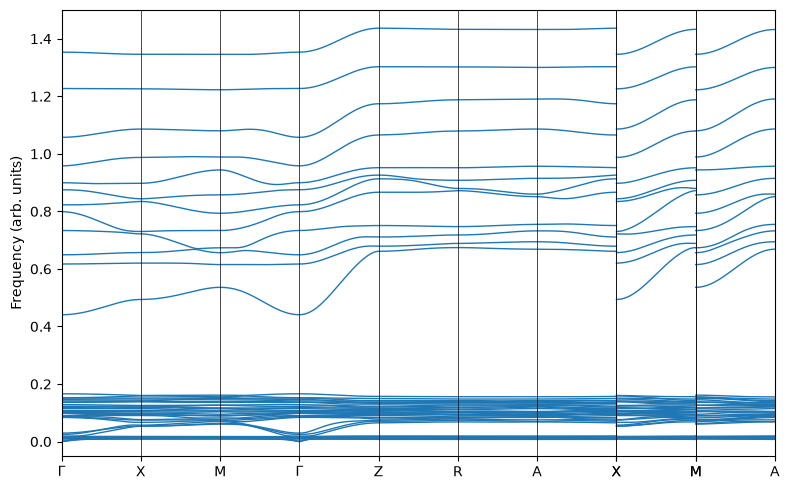

In [25]:
"""
Builds df_atoms from a gemmi structure (space-group expansion of each rigid
body's constituent atoms), and computes/plots a band structure along the
tetragonal path Gamma-X-M-Gamma-Z-R-A-Z | X-R | M-A.

Reuses skew(), T_matrix(), build_rigid_bodies() from rigid_body_dynmat.py.

IMPORTANT CONSISTENCY REQUIREMENT
----------------------------------
sym_idx here is defined as the index into gemmi.SpaceGroup(hm).operations(),
in iteration order. Whatever process built df_symmetry's sym_idx1/sym_idx2
columns MUST use this same enumeration (same space group, same operation
order, same choice of origin) -- otherwise (sym_idx, group_id) will not
consistently label the same physical rigid-body image between df_atoms and
df_symmetry. If your contact-generation code used a different tool/order to
assign sym_idx, re-derive it from this same `ops` object instead.
"""
# ----------------------------------------------------------------------
# df_atoms construction
# ----------------------------------------------------------------------

def build_df_atoms(st, groups):
    """
    st: gemmi.Structure, after st.setup_entities()
    groups: list of gemmi.Selection, one per rigid body in the asymmetric
            unit (group_id = index into this list) -- same `groups` you
            already use to build TLS groups.

    Returns a DataFrame with one row per atom, covering every
    symmetry-generated copy (sym_idx) of every rigid body (group_id) in the
    unit cell: columns sym_idx, group_id, mass, x, y, z, chain, resnum, atom_name.
    """
    sg = gemmi.SpaceGroup(st.spacegroup_hm)
    ops = sg.operations()
    cell = st.cell
    model = st[0]

    rows = []
    for sym_idx, op in enumerate(ops):
        for group_id, selection in enumerate(groups):
            sel_model = selection.copy_model_selection(model)
            for chain in sel_model:
                for residue in chain:
                    for atom in residue:
                        frac = cell.fractionalize(atom.pos)
                        frac_new = op.apply_to_xyz([frac.x, frac.y, frac.z])
                        pos_new = cell.orthogonalize(gemmi.Fractional(*frac_new))
                        rows.append({
                            'sym_idx': sym_idx,
                            'group_id': group_id,
                            'mass': atom.element.weight,
                            'x': pos_new.x,
                            'y': pos_new.y,
                            'z': pos_new.z,
                            'chain': chain.name,
                            'resnum': residue.seqid.num,
                            'atom_name': atom.name,
                        })
    return pd.DataFrame(rows)


def get_lattice(cell):
    """3x3 array, rows = real-space lattice vectors a1,a2,a3 (Cartesian, Angstrom)."""
    a1 = cell.orthogonalize(gemmi.Fractional(1, 0, 0))
    a2 = cell.orthogonalize(gemmi.Fractional(0, 1, 0))
    a3 = cell.orthogonalize(gemmi.Fractional(0, 0, 1))
    return np.array([[a1.x, a1.y, a1.z],
                      [a2.x, a2.y, a2.z],
                      [a3.x, a3.y, a3.z]])


def reciprocal_lattice(lattice):
    """3x3 array, rows = reciprocal lattice vectors b1,b2,b3 (with 2*pi convention)."""
    a1, a2, a3 = lattice
    V = np.dot(a1, np.cross(a2, a3))
    b1 = 2 * np.pi * np.cross(a2, a3) / V
    b2 = 2 * np.pi * np.cross(a3, a1) / V
    b3 = 2 * np.pi * np.cross(a1, a2) / V
    return np.array([b1, b2, b3])


# ----------------------------------------------------------------------
# sparse real-space blocks, suitable for evaluating D(q) at arbitrary q
# ----------------------------------------------------------------------

def accumulate_sparse_blocks(df_symmetry, body_index, CM, lattice):
    """
    Same geometric construction as accumulate_real_space_blocks in
    rigid_body_dynmat.py, but keeps Cartesian R explicitly instead of
    scattering onto a fixed grid -- for evaluating D(q) at off-grid q
    (e.g. a band-structure path) by direct phase summation.

    Returns sparse_L, sparse_T: dict (w, mu, nu) -> list of (Rcart, 6x6 block)
    """
    sparse_L = defaultdict(list)
    sparse_T = defaultdict(list)

    for row in df_symmetry.itertuples(index=False):
        w = row.index
        mu = body_index[(row.sym_idx1, row.group_id1)]
        nu = body_index[(row.sym_idx2, row.group_id2)]

        Rvec = np.asarray(row.pbc_shift, dtype=int)
        Rcart = Rvec @ lattice

        r1 = np.asarray(row.r1, dtype=float)
        r2 = np.asarray(row.r2, dtype=float)
        dr1 = r1 - CM[mu]
        dr2 = (r2 - Rcart) - CM[nu]

        d = r1 - r2
        n = d / np.linalg.norm(d)
        Phi_L = np.outer(n, n)
        Phi_T = np.eye(3) - Phi_L

        T1 = T_matrix(dr1)
        T2 = T_matrix(dr2)

        blk11_L = T1.T @ Phi_L @ T1
        blk22_L = T2.T @ Phi_L @ T2
        blk12_L = -T1.T @ Phi_L @ T2
        blk21_L = blk12_L.T

        blk11_T = T1.T @ Phi_T @ T1
        blk22_T = T2.T @ Phi_T @ T2
        blk12_T = -T1.T @ Phi_T @ T2
        blk21_T = blk12_T.T

        R0 = np.zeros(3)
        sparse_L[(w, mu, mu)].append((R0, blk11_L))
        sparse_L[(w, nu, nu)].append((R0, blk22_L))
        sparse_L[(w, mu, nu)].append((Rcart, blk12_L))
        sparse_L[(w, nu, mu)].append((-Rcart, blk21_L))

        sparse_T[(w, mu, mu)].append((R0, blk11_T))
        sparse_T[(w, nu, nu)].append((R0, blk22_T))
        sparse_T[(w, mu, nu)].append((Rcart, blk12_T))
        sparse_T[(w, nu, mu)].append((-Rcart, blk21_T))

    return sparse_L, sparse_T


def build_Dq(q, sparse_L, sparse_T, kL, kT, Linv, M):
    """Direct evaluation of the mass-weighted 6M x 6M D(q) at one Cartesian q."""
    D = np.zeros((M, M, 6, 6), dtype=complex)

    for (w, mu, nu), entries in sparse_L.items():
        acc = sum(blk * np.exp(1j * np.dot(q, R)) for R, blk in entries)
        D[mu, nu] += kL[w] * acc
    for (w, mu, nu), entries in sparse_T.items():
        acc = sum(blk * np.exp(1j * np.dot(q, R)) for R, blk in entries)
        D[mu, nu] += kT[w] * acc

    Dq = np.zeros((6 * M, 6 * M), dtype=complex)
    for mu in range(M):
        for nu in range(M):
            Dq[6*mu:6*mu+6, 6*nu:6*nu+6] = Linv[mu] @ D[mu, nu] @ Linv[nu].T
    return Dq


# ----------------------------------------------------------------------
# band path: Gamma-X-M-Gamma-Z-R-A-Z | X-R | M-A  (simple tetragonal, TET)
# ----------------------------------------------------------------------

HIGH_SYM_POINTS = {
    'G': np.array([0.0, 0.0, 0.0]),
    'X': np.array([0.5, 0.0, 0.0]),
    'M': np.array([0.5, 0.5, 0.0]),
    'Z': np.array([0.0, 0.0, 0.5]),
    'R': np.array([0.5, 0.0, 0.5]),
    'A': np.array([0.5, 0.5, 0.5]),
}
PATH_SEQ = ['G', 'X', 'M', 'G', 'Z', 'R', 'A', 'Z', '|', 'X', 'R', '|', 'M', 'A']


def build_path(recip_lattice, n_per_segment=40):
    """
    Returns:
        qs   : (Npts,3) Cartesian q along the path
        xs   : (Npts,) path coordinate for plotting (uniform per segment)
        ticks, ticklabels : positions/labels of high-symmetry points
        breaks : indices (into qs/xs, pre-insertion) marking each '|'
                 discontinuity -- pass to plot_bands so the corresponding
                 segments aren't drawn as connected.
    """
    qs, xs, ticks, ticklabels, breaks = [], [], [], [], []
    x = 0.0
    i = 0
    need_start_point = True  # True right after Gamma and right after each '|'
    while i < len(PATH_SEQ):
        if PATH_SEQ[i] == '|':
            breaks.append(len(xs))  # break falls right before the next segment
            need_start_point = True
            i += 1
            continue
        start = PATH_SEQ[i]
        ticks.append(x)
        ticklabels.append(r'$\Gamma$' if start == 'G' else start)
        if need_start_point:
            qs.append(HIGH_SYM_POINTS[start] @ recip_lattice)
            xs.append(x)
            need_start_point = False
        if i + 1 >= len(PATH_SEQ) or PATH_SEQ[i + 1] == '|':
            i += 1
            continue
        end = PATH_SEQ[i + 1]
        p0 = HIGH_SYM_POINTS[start] @ recip_lattice
        p1 = HIGH_SYM_POINTS[end] @ recip_lattice
        for n in range(1, n_per_segment + 1):
            t = n / n_per_segment
            qs.append((1 - t) * p0 + t * p1)
            xs.append(x + t)
        x += 1.0
        i += 1
    return np.array(qs), np.array(xs), ticks, ticklabels, breaks


def compute_bands(qs, sparse_L, sparse_T, kL, kT, Linv, M):
    n_modes = 6 * M
    bands = np.zeros((len(qs), n_modes))
    for idx, q in enumerate(qs):
        Dq = build_Dq(q, sparse_L, sparse_T, kL, kT, Linv, M)
        Dq = 0.5 * (Dq + Dq.conj().T)  # clean up numerical Hermiticity
        bands[idx] = np.linalg.eigvalsh(Dq)
    return bands


def _insert_breaks(xs, bands, breaks):
    """Insert a NaN row/x-value at each break index so matplotlib doesn't
    draw a connecting line across it. Processed back-to-front so earlier
    insertion indices stay valid."""
    xs = list(xs)
    bands = list(bands)
    for b in sorted(breaks, reverse=True):
        bands.insert(b, np.full(len(bands[0]), np.nan))
        xs.insert(b, xs[b])  # x-value is irrelevant; NaN in y breaks the line
    return np.array(xs), np.array(bands)


def plot_bands(bands, xs, ticks, ticklabels, ymin, ymax, breaks=()):
    freqs = np.sqrt(np.clip(bands, 0, None))  # eigenvalues of D are omega^2
    xs_plot, freqs_plot = _insert_breaks(xs, freqs, breaks)
    plt.figure(figsize=(8, 5))
    for m in range(freqs_plot.shape[1]):
        plt.plot(xs_plot, freqs_plot[:, m], color='C0', lw=1)
    for t in ticks:
        plt.axvline(t, color='k', lw=0.5)
    plt.xticks(ticks, ticklabels)
    plt.xlim(ticks[0], ticks[-1])
    plt.ylim(ymin, ymax)
    plt.ylabel('Frequency (arb. units)')
    plt.tight_layout()
    plt.show()


# ----------------------------------------------------------------------
# example usage
# ----------------------------------------------------------------------

if __name__ == '__main__':
    coordinate_file = 'test_data/7TX0.cif'
    st = gemmi.read_structure(coordinate_file)
    st.setup_entities()

    groups = [
        gemmi.Selection('//A;polymer'),
        gemmi.Selection('//B;polymer'),
    ]

    # 1. build df_atoms via space-group expansion
    df_atoms = build_df_atoms(st, groups)

    # 2. rigid-body geometry: CM, generalized mass matrix, Cholesky
    body_index, CM, L = build_rigid_bodies(df_atoms)
    M = len(body_index)
    Linv = np.linalg.inv(L)

    # 3. lattice / reciprocal lattice
    lattice = get_lattice(st.cell)
    recip = reciprocal_lattice(lattice)

    # 4. df_symmetry assumed already built elsewhere in your pipeline, with
    #    sym_idx matching the SAME gemmi.SpaceGroup(...).operations() order
    #    used inside build_df_atoms.
    # df_symmetry = ...

    sparse_L, sparse_T = accumulate_sparse_blocks(df_symmetry, body_index, CM, lattice)

    # 5. placeholder spring constants -- one per symmetry class, replace
    #    with refined values
    classes = sorted(df_symmetry['index'].unique())
    kL = {w: 1.0 for w in classes}
    kT = {w: 0.5 for w in classes}

    # 6. path, bands, plot
    qs, xs, ticks, ticklabels, breaks = build_path(recip, n_per_segment=100)
    bands = compute_bands(qs, sparse_L, sparse_T, kL, kT, Linv, M)
    plot_bands(bands, xs, ticks, ticklabels, -0.05, 1.5, breaks=breaks)

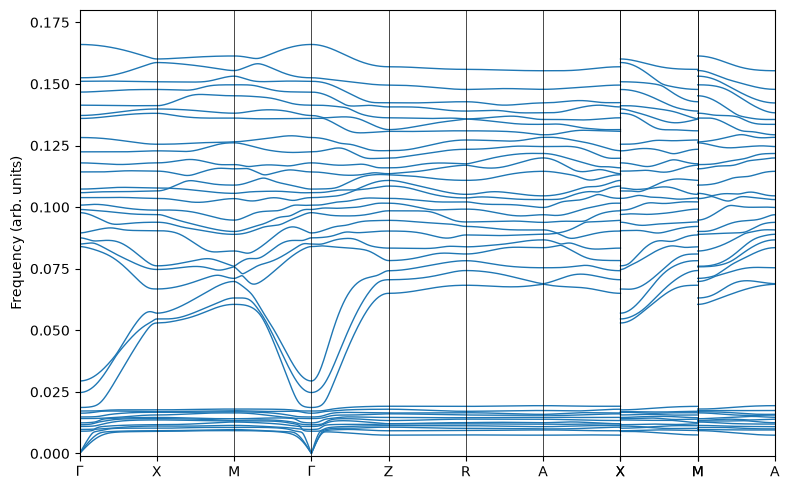

In [26]:
plot_bands(bands, xs, ticks, ticklabels, -0.001, 0.18, breaks=breaks)

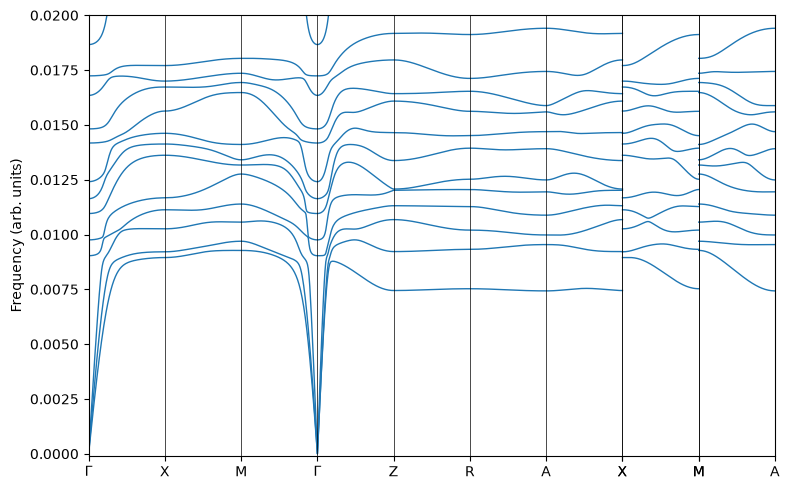

In [27]:
plot_bands(bands, xs, ticks, ticklabels, -0.0001, 0.02, breaks=breaks)